# Feature Signal + Unsupervised Analysis

This notebook uses finalized pipeline outputs to ensure consistency and avoid leakage:

- Signal discovery on `X_train_imputed` with `y_train`
- Unsupervised dimensionality reduction on sparse `X_train_ohe` via `TruncatedSVD`

All model-fitting steps in this notebook use train artifacts only.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.sparse import issparse
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import TruncatedSVD

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

(139991, 100)
   activity_year                   lei  derived_msa-md state_code  \
0           2019  KB1H1DSPRFMYMCUFXT09           44700         CA   
1           2019  5493001SXWZ4OFP8Z903           26420         TX   
2           2019  7H6GLXDRUGQFU57RNE97           41700         TX   

   county_code  census_tract conforming_loan_limit derived_loan_product_type  \
0       6077.0  6.077001e+09                     C   Conventional:First Lien   
1      48201.0  4.820154e+10                     C            FHA:First Lien   
2      48029.0  4.802912e+10                     C   Conventional:First Lien   

              derived_dwelling_category       derived_ethnicity derived_race  \
0  Single Family (1-4 Units):Site-Built      Hispanic or Latino        White   
1  Single Family (1-4 Units):Site-Built      Hispanic or Latino        White   
2  Single Family (1-4 Units):Site-Built  Not Hispanic or Latino        Asian   

  derived_sex  action_taken  purchaser_type  preapproval  loan_type

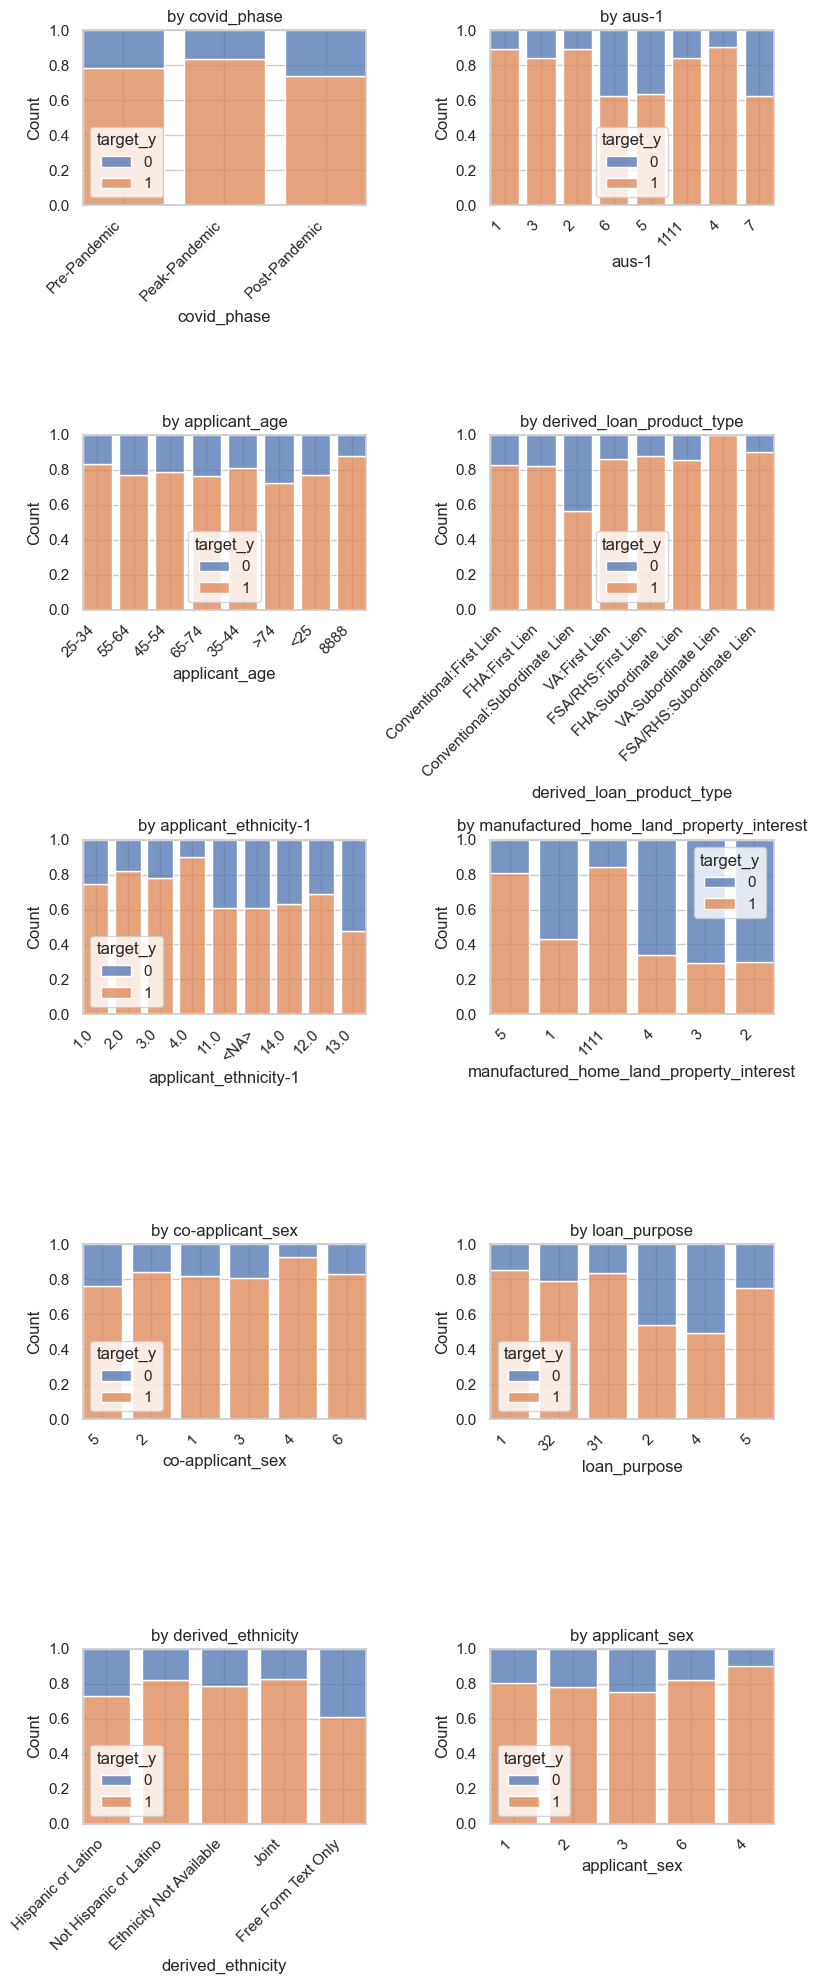

--- Data Processing Complete ---
Final columns: ['state_code', 'conforming_loan_limit', 'derived_dwelling_category', 'derived_ethnicity', 'derived_sex', 'preapproval', 'loan_type', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'origination_charges', 'discount_points', 'lender_credits', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'income', 'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed', 'applicant_race_observed', 'co-applicant_race_observed', 'applicant_sex_observed', 'co-applicant_sex_observed', 'applicant_age_above_62', 'co-applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'tract_population', 'tract_minority_populatio

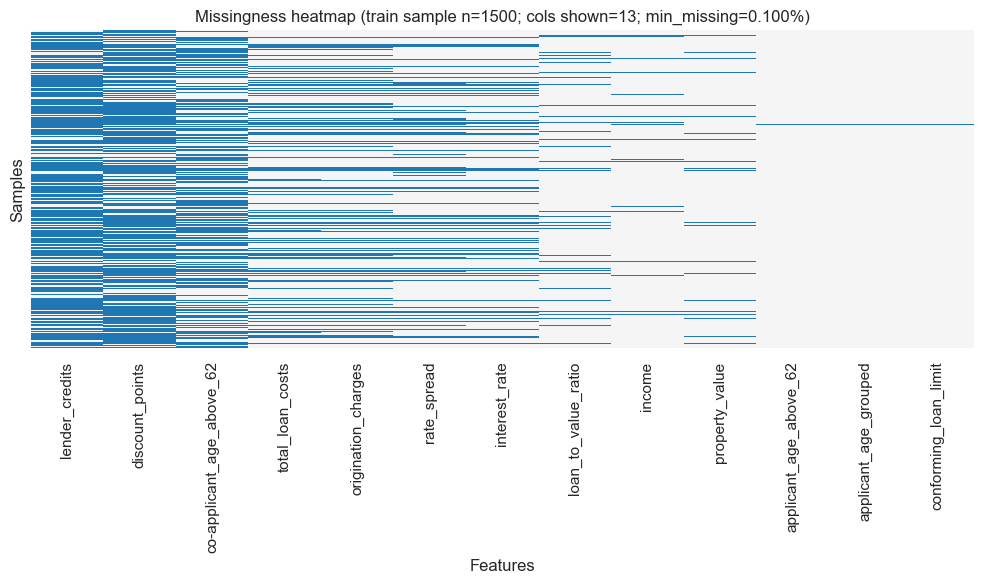

Top missing-rate features shown (train, before imputation) [%]:
lender_credits               72.44
discount_points              71.14
co-applicant_age_above_62    54.06
total_loan_costs             33.17
origination_charges          32.45
rate_spread                  27.73
interest_rate                21.53
loan_to_value_ratio           8.89
income                        7.03
property_value                4.97
applicant_age_above_62        1.50
applicant_age_grouped         1.50
conforming_loan_limit         0.48
dtype: float64
--- Imputation plan (decided on TRAIN only) ---
Numeric cols: 18
  mean-impute (|skew| <= 0.75): 4
  median-impute (|skew| > 0.75): 14
Categorical cols (mode-impute): 31
Regression/iterative imputation applied to costs/fees: ['total_loan_costs', 'origination_charges', 'discount_points', 'lender_credits']
Regression/iterative imputation applied to property/loan/income: ['property_value', 'loan_amount', 'income']

Sanity checks:
Any NA in X_train_imputed? False
An

In [2]:
# Require finalized pipeline artifacts from data.ipynb.
required_vars = ["X_train_imputed", "y_train", "X_train_ohe"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    try:
        get_ipython().run_line_magic("run", "data.ipynb")
    except Exception as exc:
        raise NameError(
            "Missing required pipeline variables and auto-running `data.ipynb` failed: "
            f"{missing}. Run `data.ipynb` first."
        ) from exc

missing_after = [v for v in required_vars if v not in globals()]
if missing_after:
    raise NameError(f"Missing required pipeline variables after setup: {missing_after}")

# Align target as a clean Series for association tests.
y_train_series = pd.Series(y_train).reset_index(drop=True)
if y_train_series.name is None:
    y_train_series.name = "target_y"

# Shape and type guardrails.
if X_train_imputed.shape[0] != len(y_train_series):
    raise ValueError("Row mismatch: X_train_imputed and y_train must align.")
if X_train_ohe.shape[0] != len(y_train_series):
    raise ValueError("Row mismatch: X_train_ohe and y_train must align.")

is_sparse_ohe = issparse(X_train_ohe)

numeric_cols = X_train_imputed.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_imputed.columns if c not in numeric_cols]

print("X_train_imputed shape:", X_train_imputed.shape)
print("X_train_ohe shape:", X_train_ohe.shape)
print("y_train length:", len(y_train_series))
print("X_train_ohe is sparse:", is_sparse_ohe)
print("Numeric columns in X_train_imputed:", len(numeric_cols))
print("Categorical columns in X_train_imputed:", len(cat_cols))

In [3]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramer's V for categorical association."""
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid.empty:
        return np.nan

    confusion = pd.crosstab(valid["x"], valid["y"])
    if confusion.empty or confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return np.nan

    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return np.nan

    return float(np.sqrt(phi2_corr / denom))


def safe_pointbiserial(feature: pd.Series, target: pd.Series):
    valid = pd.DataFrame({"x": feature, "y": target}).dropna()
    if valid["x"].nunique() < 2:
        return np.nan, np.nan
    r, p = stats.pointbiserialr(valid["y"], valid["x"])
    return float(r), float(p)

In [4]:
# 1) Signal feature discovery vs target_y on finalized train-imputed data

# Numeric associations: point-biserial + spearman
num_rows = []
for col in numeric_cols:
    r_pb, p_pb = safe_pointbiserial(X_train_imputed[col], y_train_series)
    spear = pd.DataFrame({"x": X_train_imputed[col], "y": y_train_series}).dropna()
    if spear["x"].nunique() > 1:
        r_sp, p_sp = stats.spearmanr(spear["x"], spear["y"])
    else:
        r_sp, p_sp = (np.nan, np.nan)

    num_rows.append({
        "feature": col,
        "pointbiserial_r": r_pb,
        "pointbiserial_p": p_pb,
        "spearman_r": float(r_sp) if pd.notna(r_sp) else np.nan,
        "spearman_p": float(p_sp) if pd.notna(p_sp) else np.nan,
        "abs_pointbiserial_r": abs(r_pb) if pd.notna(r_pb) else np.nan,
    })

numeric_signal = (
    pd.DataFrame(num_rows)
    .sort_values("abs_pointbiserial_r", ascending=False)
    .reset_index(drop=True)
)

# Categorical associations: Cramer's V + MI
cat_rows = []
if cat_cols:
    X_cat_train = X_train_imputed[cat_cols].copy()
    for c in cat_cols:
        X_cat_train[c] = X_cat_train[c].astype("category")

    X_cat_codes = np.column_stack([
        X_cat_train[c].cat.codes.replace(-1, np.nan).fillna(-1).astype(int).values
        for c in cat_cols
    ])
    mi_vals = mutual_info_classif(X_cat_codes, y_train_series.values, discrete_features=True, random_state=42)

    for i, col in enumerate(cat_cols):
        cat_rows.append({
            "feature": col,
            "cramers_v": cramers_v(X_train_imputed[col], y_train_series),
            "mutual_info": float(mi_vals[i]),
        })

categorical_signal = (
    pd.DataFrame(cat_rows)
    .sort_values(["cramers_v", "mutual_info"], ascending=False)
    .reset_index(drop=True)
    if cat_rows else pd.DataFrame(columns=["feature", "cramers_v", "mutual_info"])
)

print("Top numeric signal features")
display(numeric_signal.head(20))

print("Top categorical signal features")
display(categorical_signal.head(20))

Top numeric signal features


,feature,pointbiserial_r,pointbiserial_p,spearman_r,spearman_p,abs_pointbiserial_r
0,tract_one_to_four_family_homes,-0.008208,0.013987,-0.008727,0.008978,0.008208
1,tract_owner_occupied_units,-0.006526,0.050694,-0.006577,0.048915,0.006526
2,loan_to_value_ratio,-0.006187,0.063958,-0.003557,0.286917,0.006187
3,tract_population,-0.006172,0.064590,-0.006022,0.071380,0.006172
4,interest_rate,-0.004948,0.138501,-0.003270,0.327522,0.004948
5,ffiec_msa_md_median_family_income,0.004533,0.174679,0.004388,0.188965,0.004533
6,loan_amount,-0.003458,0.300562,-0.003926,0.239773,0.003458
7,lender_credits,0.003370,0.313035,0.004769,0.153327,0.003370
8,rate_spread,-0.002603,0.435693,-0.000779,0.815672,0.002603
9,tract_to_msa_income_percentage,0.002570,0.441656,0.002821,0.398328,0.002570


Top categorical signal features


,feature,cramers_v,mutual_info
0,lien_status,0.005502,0.020004
1,loan_product_grouped,0.005502,0.020004
2,loan_purpose_grouped,0.004385,0.027730
3,state_code,0.004225,0.001262
4,derived_ethnicity,0.003329,0.003589
5,construction_method,0.002568,0.015717
6,applicant_sex_observed,0.002096,0.000866
7,covid_phase,0.001855,0.005744
8,manufactured_home_grouped,0.000403,0.015788
9,hoepa_status,0.000000,0.325540


Highly redundant numeric pairs (|Spearman| >= 0.8)


,feature_1,feature_2,spearman_corr,abs_corr
147,tract_owner_occupied_units,tract_one_to_four_family_homes,0.896086,0.896086


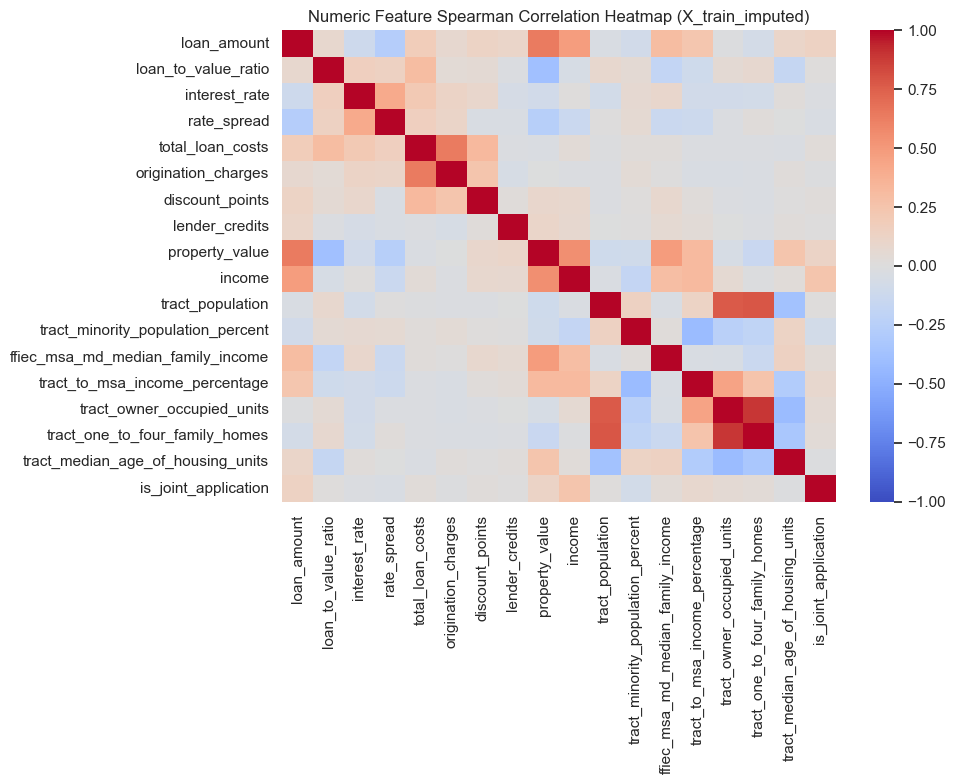

In [5]:
# 2) Redundancy check among numeric predictors on X_train_imputed

if numeric_cols:
    corr_spearman = X_train_imputed[numeric_cols].corr(method="spearman")

    corr_long = (
        corr_spearman.where(np.triu(np.ones(corr_spearman.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    corr_long.columns = ["feature_1", "feature_2", "spearman_corr"]
    corr_long["abs_corr"] = corr_long["spearman_corr"].abs()

    high_corr_pairs = corr_long[corr_long["abs_corr"] >= 0.8].sort_values("abs_corr", ascending=False)

    print("Highly redundant numeric pairs (|Spearman| >= 0.8)")
    display(high_corr_pairs.head(30))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_spearman, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Numeric Feature Spearman Correlation Heatmap (X_train_imputed)")
    plt.tight_layout()
    plt.show()
else:
    corr_spearman = pd.DataFrame()
    high_corr_pairs = pd.DataFrame(columns=["feature_1", "feature_2", "spearman_corr", "abs_corr"])
    print("No numeric columns available for redundancy check.")

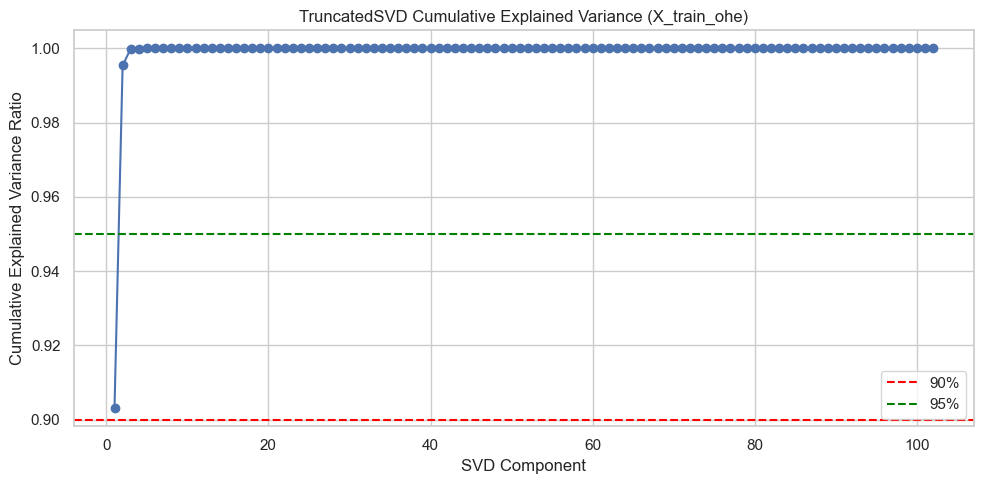

SVD components for >=90% variance: 1
SVD components for >=95% variance: 2


,component,feature,loading
0,SVD1,property_value,0.885900
1,SVD1,loan_amount,0.457182
2,SVD1,ffiec_msa_md_median_family_income,0.078176
3,SVD1,total_loan_costs,0.004718
4,SVD1,tract_population,0.004516
5,SVD1,discount_points,0.002079
6,SVD1,origination_charges,0.001995
7,SVD1,tract_one_to_four_family_homes,0.001381
8,SVD1,tract_owner_occupied_units,0.001030
9,SVD1,lender_credits,0.000841


In [6]:
# 3) Unsupervised path: TruncatedSVD on finalized X_train_ohe

max_svd_components = int(min(200, X_train_ohe.shape[0] - 1, X_train_ohe.shape[1] - 1))
if max_svd_components < 2:
    raise ValueError("Not enough dimensions/samples in X_train_ohe for TruncatedSVD.")

svd_full = TruncatedSVD(n_components=max_svd_components, random_state=42)
svd_full.fit(X_train_ohe)
svd_cum_var = np.cumsum(svd_full.explained_variance_ratio_)

svd_n90 = int(np.argmax(svd_cum_var >= 0.90) + 1) if np.any(svd_cum_var >= 0.90) else max_svd_components
svd_n95 = int(np.argmax(svd_cum_var >= 0.95) + 1) if np.any(svd_cum_var >= 0.95) else max_svd_components

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(svd_cum_var) + 1), svd_cum_var, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.axhline(0.95, color="green", linestyle="--", label="95%")
plt.xlabel("SVD Component")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("TruncatedSVD Cumulative Explained Variance (X_train_ohe)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"SVD components for >=90% variance: {svd_n90}")
print(f"SVD components for >=95% variance: {svd_n95}")

svd = TruncatedSVD(n_components=svd_n95, random_state=42)
X_train_svd = svd.fit_transform(X_train_ohe)
X_test_svd = svd.transform(X_test_ohe) if "X_test_ohe" in globals() else None

# Prefer finalized pipeline feature names where available.
if "feat_names" in globals() and len(feat_names) == X_train_ohe.shape[1]:
    svd_feature_names = np.array(feat_names)
elif "encoder" in globals():
    svd_feature_names = np.array(encoder.get_feature_names_out())
else:
    svd_feature_names = np.array([f"feature_{i}" for i in range(X_train_ohe.shape[1])])

svd_loading_rows = []
for comp_idx, comp in enumerate(svd.components_[: min(5, svd.components_.shape[0])]):
    top_idx = np.argsort(np.abs(comp))[::-1][:10]
    for idx in top_idx:
        svd_loading_rows.append({
            "component": f"SVD{comp_idx+1}",
            "feature": svd_feature_names[idx],
            "loading": comp[idx],
        })

top_svd_loadings = pd.DataFrame(svd_loading_rows)
display(top_svd_loadings)

In [7]:
# 4) Modeling-phase handoff artifacts

top_numeric_features = numeric_signal["feature"].head(25).tolist() if not numeric_signal.empty else []
top_categorical_features = categorical_signal["feature"].head(25).tolist() if not categorical_signal.empty else []

recommendations = {
    "top_numeric_features": top_numeric_features,
    "top_categorical_features": top_categorical_features,
    "high_corr_numeric_pairs_count": int(len(high_corr_pairs)) if "high_corr_pairs" in globals() else 0,
    "svd_components_90": int(svd_n90) if "svd_n90" in globals() else None,
    "svd_components_95": int(svd_n95) if "svd_n95" in globals() else None,
    "x_train_ohe_is_sparse": bool(is_sparse_ohe),
}

recommendations_df = pd.DataFrame([recommendations])
display(recommendations_df)

# Optional outputs for downstream modeling cells/files
outputs = {
    "numeric_signal": numeric_signal,
    "categorical_signal": categorical_signal,
    "high_corr_pairs": high_corr_pairs,
    "top_svd_loadings": top_svd_loadings,
    "X_train_svd": X_train_svd,
    "X_test_svd": X_test_svd,
}

print("Prepared modeling handoff artifacts:")
print(list(outputs.keys()))

,top_numeric_features,top_categorical_features,high_corr_numeric_pairs_count,svd_components_90,svd_components_95,x_train_ohe_is_sparse
0,"[tract_one_to_four_family_homes, tract_owner_o...","[lien_status, loan_product_grouped, loan_purpo...",1,1,2,True


Prepared modeling handoff artifacts:
['numeric_signal', 'categorical_signal', 'high_corr_pairs', 'top_svd_loadings', 'X_train_svd', 'X_test_svd']
